# Day 9 — Machines That Act 🎮

> **Mission briefing:** Everything the Lab has built so far *perceives* — it classifies penguins, clusters colors, reads handwriting, understands words. Today we build something new: an agent that *decides*. There are no labels and no answer key — only a world, actions, and **rewards**. You will train a brain the way you would train a puppy: a treat for every good move.

**Previously in the Lab:** yesterday you unlocked the 💬 **Language Lab** and made transformer models write stories, read moods, and fill in the blanks.

**Today you will:**
- Meet **reinforcement learning** — the loop of *act → get a reward → learn*
- Teach an agent to cross a frozen lake with a **Q-table** (64 numbers that become an instinct)
- Write the single line of math — the **Q-learning update** — that sits at the heart of it
- Watch a neural network (a **Deep Q-Network**) learn to balance a pole from nothing
- See why this is how AlphaGo won, how robots learn to walk, and (as **RLHF**) part of how ChatGPT was polished

**Today you unlock:** 🔓 **🎮 Game Master** — replay both agents you trained, live in your Studio.

In [1]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║ SETUP — run me first! (identical in every Lab notebook)           ║
# ╚═══════════════════════════════════════════════════════════════════╝
import os, sys, pathlib

IN_COLAB = "google.colab" in sys.modules
SMOKE = os.environ.get("SMOKE_TEST", "0") == "1"   # tiny fast run for automated tests

REPO_URL = "https://github.com/A-Halimi/ai-studio-internship.git"  # instructor: set once

if IN_COLAB:
    if not pathlib.Path("/content/ai-studio-internship").exists():
        !git clone -q {REPO_URL} /content/ai-studio-internship
    %cd /content/ai-studio-internship/notebooks/day09                    # ← ADAPT day folder
    %pip -q install "gymnasium[classic-control,toy-text]==1.3.0" stable-baselines3==2.9.0 "imageio[ffmpeg]==2.37.3" gradio==6.19.0   # ← ADAPT per-day installs

HERE = pathlib.Path.cwd()
REPO = HERE.parents[1]                       # .../notebooks/dayNN -> repo root
DATA_DIR = pathlib.Path(os.environ.get("COURSE_DATA_DIR", REPO / "data"))
SAMPLES_DIR = REPO / "data_samples"          # small datasets shipped with the repo
MODELS_DIR = REPO / "ai_studio" / "models"   # where your Studio modules unlock
for p in (REPO / "data", MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)

import random
import numpy as np
SEED = 42
random.seed(SEED); np.random.seed(SEED)
print(f"✅ Setup done | Colab: {IN_COLAB} | Smoke test: {SMOKE}")
print(f"   data: {DATA_DIR}")

✅ Setup done | Colab: False | Smoke test: False
   data: /opt/course/data


In [2]:
import torch
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    print(f"⚡ Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    print("🐢 No GPU found — running on CPU. Everything still works, just slower.")

⚡ Running on GPU: NVIDIA RTX PRO 5000 Blackwell Generation Laptop GPU


In [3]:
# ── CONFIG — the Lab's control panel. Tweak me later! ──────────────
EPISODES  = 300 if SMOKE else 3000     # Q-learning episodes on FrozenLake
TIMESTEPS = 3_000 if SMOKE else 60_000 # Deep-Q-Network training steps on CartPole
ALPHA = 0.8    # learning rate for the Q-table (how big a step we take)
GAMMA = 0.95   # discount: how much the agent values *future* rewards (patience)
print(f"EPISODES={EPISODES} | TIMESTEPS={TIMESTEPS} | ALPHA={ALPHA} | GAMMA={GAMMA}")

EPISODES=3000 | TIMESTEPS=60000 | ALPHA=0.8 | GAMMA=0.95


## 1 · The reinforcement-learning loop

Supervised learning (Days 2–8) needs an **answer key**: a photo *labeled* "cat", a review *labeled* "positive". Reinforcement learning throws the answer key away. Instead there is a loop:

> The **agent** looks at the current **state**, picks an **action**, and the **environment** replies with a **reward** and a new state. Repeat thousands of times. The agent's only goal: collect as much reward as possible over the long run.

```
        ┌──────────────────────────────────────────┐
        │                                          │
   ┌────▼────┐   action a    ┌───────────────┐     │
   │  AGENT  │ ────────────▶ │  ENVIRONMENT  │     │
   │ (brain) │               │   (a world)   │     │
   └─────────┘ ◀──────────── └───────────────┘     │
        │        reward r + new state s'           │
        └──────────────────────────────────────────┘
```

The agent is never *told* the right move. It has to **discover** which moves pay off, purely from the rewards. That is the whole idea — and it is remarkably general:

| Situation | The reward the agent chases |
|---|---|
| Playing a video game | the score going up |
| A robot learning to walk | distance covered without falling over |
| A self-driving car | staying in its lane and reaching the destination |
| Polishing ChatGPT (**RLHF**) | a human clicking 👍 instead of 👎 |

One loop, a thousand applications. Let's build the smallest possible version of it.

## 2 · Meet FrozenLake ❄️

Our first world is a tiny 4×4 frozen pond from the **Gymnasium** library (the standard toolbox of RL practice environments). The rules:

- The agent starts at **S** (top-left) and wants the **gift** 🎁 at **G** (bottom-right).
- Some tiles are **holes** (H) — step on one and the episode ends with nothing.
- **16 states** (the tiles, numbered 0–15) and **4 actions**: `0=LEFT  1=DOWN  2=RIGHT  3=UP`.
- **Reward = 1** *only* when it reaches the gift. Every other step gives **0**.

That last point is what makes this hard: the agent gets almost no feedback. It has to stumble onto the gift by luck at least once, then learn to repeat the path. We use `is_slippery=False` so the ice behaves predictably — a move you choose is the move you make.

Number of states : 16
Number of actions: 4
The pond (S=start  F=frozen  H=hole  G=gift):
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]


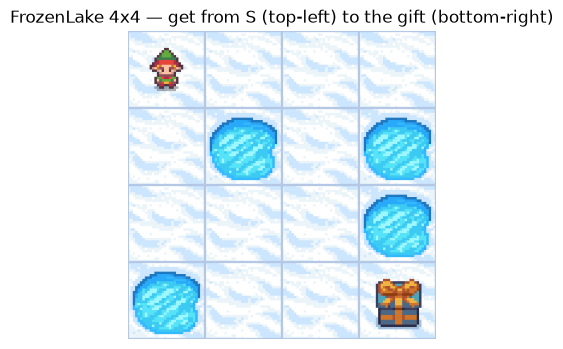

In [4]:
os.environ.setdefault("SDL_VIDEODRIVER", "dummy")   # let pygame draw with no screen (cloud/headless)
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False,
               render_mode="rgb_array")
state, _ = env.reset(seed=SEED)

print("Number of states :", env.observation_space.n)   # 16 tiles
print("Number of actions:", env.action_space.n)        # 4 moves (L, D, R, U)
print("The pond (S=start  F=frozen  H=hole  G=gift):")
print(env.unwrapped.desc.astype(str))

plt.figure(figsize=(4, 4))
plt.imshow(env.render())
plt.axis("off")
plt.title("FrozenLake 4x4 — get from S (top-left) to the gift (bottom-right)")
plt.show()

### 🧪 Exercise 1 — how far does *pure luck* get?

Before we teach the agent anything, let's measure the baseline: an agent that ignores everything and picks **random** moves.

- Run many episodes where every action comes from `env.action_space.sample()`.
- Count how often it stumbles onto the gift, and report the success rate.

Expected outcome: a dismal **~1–5%**. Wandering blindly across ice rarely ends well.

In [5]:
N_RANDOM = 200 if SMOKE else 1000
env.action_space.seed(SEED)          # make the "random" moves reproducible

wins = 0
for episode in range(N_RANDOM):
    state, _ = env.reset()
    done = False
    ### BEGIN SOLUTION
    while not done:
        action = env.action_space.sample()          # a totally random move
        ### HINT: env.action_space.sample() returns a random action (0-3)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
    wins += int(reward > 0)                          # reward is 1.0 only at the gift
    ### HINT: after the episode, reward > 0 means it finished on the gift
    ### END SOLUTION

success_rate = wins / N_RANDOM
print(f"🎲 Random agent reached the gift in {success_rate:.1%} of {N_RANDOM} episodes")

🎲 Random agent reached the gift in 1.4% of 1000 episodes


## 3 · The Q-table — the agent's cheat sheet

Here is the key idea. Imagine a table with **one row per state** and **one column per action**. Each cell holds a single number, `Q(state, action)` — the agent's estimate of *"how good is it to take this action from this state, if I play well afterward?"*

For FrozenLake that's a **16 × 4 = 64-number** table. If the agent could fill it in correctly, choosing the best move would be trivial: in any state, look at that row and pick the column with the biggest number.

The agent starts knowing **nothing**, so every cell begins at zero:

In [6]:
q = np.zeros((16, 4))     # 16 states (rows) x 4 actions (columns)
print("The Q-table starts as all zeros — the agent knows nothing yet:")
print(q)
print("Shape:", q.shape, "→ one row per state, one column per action")

The Q-table starts as all zeros — the agent knows nothing yet:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Shape: (16, 4) → one row per state, one column per action


### 🧪 Exercise 2 — explore vs. exploit (`choose_action`)

An agent that always picks the highest number in its table will keep repeating whatever it tried first — it never discovers better moves. An agent that always moves randomly never *uses* what it learned. The fix is **ε-greedy**:

- With probability **ε** (epsilon): **explore** — take a random action.
- Otherwise: **exploit** — take the action with the largest Q-value for this state.

It's the restaurant dilemma: most nights you go to your favorite (exploit), but once in a while you try somewhere new (explore) in case it's even better. Fill in `choose_action`.

In [7]:
def choose_action(state, q, eps):
    """Epsilon-greedy: explore with probability eps, otherwise exploit the Q-table."""
    ### BEGIN SOLUTION
    if np.random.random() < eps:
        return env.action_space.sample()          # explore: try something new
        ### HINT: np.random.random() draws a float in [0, 1)
    return int(np.argmax(q[state]))               # exploit: best known action
    ### HINT: np.argmax(q[state]) is the column with the biggest Q-value for this state
    ### END SOLUTION

# quick check: with eps=0 it must ALWAYS pick the greedy action
_probe = np.zeros((16, 4)); _probe[3] = [0, 0, 9, 0]
assert choose_action(3, _probe, eps=0.0) == 2, "With eps=0 you should always exploit!"
print("✅ choose_action works — with eps=0 it picks the best action (column 2 here).")

✅ choose_action works — with eps=0 it picks the best action (column 2 here).


### 🧪 Exercise 3 — start bold, end wise (`get_epsilon`)

Early in training the agent should **explore a lot** (it knows nothing). Later it should mostly **exploit** what it has learned. So we let ε **decay** over the run — from `1.0` (all exploration) down to `0.01` (almost always greedy).

Write a **linear** schedule: on episode `0` return `EPS_START`; on the final episode return (about) `EPS_END`; blend smoothly in between.

In [8]:
EPS_START, EPS_END = 1.0, 0.01
def get_epsilon(episode, n_episodes):
    """Linear decay from EPS_START (all exploration) to EPS_END (almost all exploit)."""
    ### BEGIN SOLUTION
    frac = episode / max(1, n_episodes - 1)       # 0.0 on the first episode, 1.0 on the last
    ### HINT: frac should run from 0 (first episode) to 1 (last episode)
    return EPS_START + frac * (EPS_END - EPS_START)
    ### HINT: blend EPS_START and EPS_END using frac
    ### END SOLUTION

assert abs(get_epsilon(0, EPISODES) - 1.0) < 1e-9, "Episode 0 should be full exploration"
assert get_epsilon(EPISODES - 1, EPISODES) <= 0.02, "The last episode should be near-greedy"
print(f"✅ epsilon starts at {get_epsilon(0, EPISODES):.2f} "
      f"and ends at {get_epsilon(EPISODES-1, EPISODES):.2f}")

✅ epsilon starts at 1.00 and ends at 0.01


## 4 · ★ The Q-learning update — the heart of it all

Every time the agent takes action `a` in state `s`, lands in state `s'`, and collects reward `r`, it improves **one cell** of its table with this rule:

> **new opinion of (s, a)  =  old opinion  +  ALPHA × ( reward  +  GAMMA × best future value  −  old opinion )**

In code, that's a single line:

```python
q[s, a] += ALPHA * (r + GAMMA * np.max(q[s_next]) - q[s, a])
```

Read it slowly. `r + GAMMA * np.max(q[s_next])` is a **fresh estimate** of how good `(s, a)` really was — the reward we just got, plus the discounted value of the *best* move available from where we landed. We nudge the old value a fraction `ALPHA` of the way toward that fresh estimate. Do this a few thousand times and the table fills itself in.

<details><summary>🔢 <b>Math Corner</b> — the update in symbols (optional)</summary>

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,\big[\, r + \gamma \max_{a'} Q(s',a') - Q(s,a) \,\big]$$

- $Q(s,a)$ — how good we *currently* think action $a$ is in state $s$.
- $r$ — the reward we just received.
- $\max_{a'} Q(s',a')$ — the value of the **best** move from the new state $s'$.
- $\gamma$ (GAMMA) — a **patience knob** in $[0,1]$: near $0$ chases reward *now*; near $1$ plans far ahead.
- $\alpha$ (ALPHA) — the **learning rate**: the step size toward the new estimate.

The bracketed part is the **temporal-difference error** — the gap between what we expected and what happened. Learning is just shrinking that gap.

</details>

### 🧪 Exercise 4 — train the agent (the crown jewel) 👑

Everything comes together in one loop. For each episode we reset the pond, decay ε, then step until the episode ends — choosing an action and updating the table each step. **Two lines are yours to fill:**

1. Pick the action with the `choose_action` function you wrote.
2. Apply the **Q-learning update** from the section above.

Watch the printed success rate climb from near-zero toward **100%**.

In [9]:
q = np.zeros((16, 4))          # start again from a blank cheat sheet
successes = []                  # 1.0 if the episode reached the gift, else 0.0

for episode in range(EPISODES):
    state, _ = env.reset()
    eps = get_epsilon(episode, EPISODES)
    done = False
    while not done:
        ### BEGIN SOLUTION
        action = choose_action(state, q, eps)      # explore or exploit
        ### HINT: reuse the choose_action function you wrote in Exercise 2
        ### END SOLUTION
        next_state, reward, terminated, truncated, _ = env.step(action)
        ### BEGIN SOLUTION
        q[state, action] += ALPHA * (reward + GAMMA * np.max(q[next_state]) - q[state, action])
        ### HINT: new = old + ALPHA * (reward + GAMMA * best_next - old)
        ### END SOLUTION
        state = next_state
        done = terminated or truncated
    successes.append(1.0 if reward > 0 else 0.0)

    if (episode + 1) % max(1, EPISODES // 10) == 0:
        recent = np.mean(successes[-100:])
        print(f"  episode {episode+1:>5}/{EPISODES} | eps={eps:4.2f} | recent success = {recent:5.1%}")

print("🏁 Training done!")

  episode   300/3000 | eps=0.90 | recent success =  4.0%
  episode   600/3000 | eps=0.80 | recent success =  7.0%
  episode   900/3000 | eps=0.70 | recent success = 16.0%
  episode  1200/3000 | eps=0.60 | recent success = 23.0%
  episode  1500/3000 | eps=0.51 | recent success = 45.0%
  episode  1800/3000 | eps=0.41 | recent success = 52.0%
  episode  2100/3000 | eps=0.31 | recent success = 69.0%
  episode  2400/3000 | eps=0.21 | recent success = 87.0%
  episode  2700/3000 | eps=0.11 | recent success = 91.0%
  episode  3000/3000 | eps=0.01 | recent success = 99.0%
🏁 Training done!


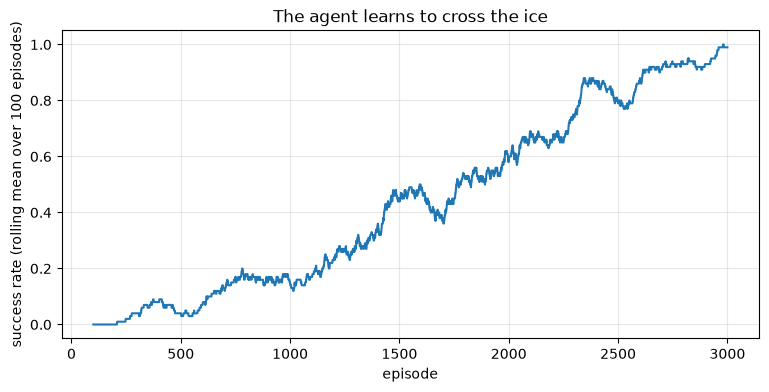

In [10]:
window = 100
rolling = np.convolve(successes, np.ones(window) / window, mode="valid")
plt.figure(figsize=(9, 4))
plt.plot(range(window, window + len(rolling)), rolling)
plt.xlabel("episode")
plt.ylabel(f"success rate (rolling mean over {window} episodes)")
plt.title("The agent learns to cross the ice")
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.show()

### 🧪 Exercise 5 — how good did it get?

Measure the agent's skill at the *end* of training: the mean success over the **last 200 episodes**. For a non-slippery 4×4 pond a trained agent should be essentially perfect.

In [11]:
### BEGIN SOLUTION
final_success = np.mean(successes[-200:])         # success over the last 200 episodes
### HINT: slice the last 200 with successes[-200:], then np.mean(...)
### END SOLUTION
print(f"🎯 Success over the last 200 training episodes: {final_success:.1%}")
if not SMOKE:
    assert final_success >= 0.9, "Below 90% — double-check your Q-update line!"
    print("✅ The agent has essentially mastered the pond.")

🎯 Success over the last 200 training episodes: 96.0%
✅ The agent has essentially mastered the pond.


## 5 · Look inside the brain

Those 64 numbers *are* the agent's mind. From them we can read out its complete strategy — a **policy**: in each state, the single best move.

### 🧪 Exercise 6 — read out the policy

Collapse each row of the table into two summaries:

- `best_action` — for every state, the action with the largest Q-value.
- `best_value` — for every state, how large that best value is.

Both are one call to a NumPy function along **axis 1** (across the 4 action-columns).

In [12]:
### BEGIN SOLUTION
best_action = np.argmax(q, axis=1)     # the single best move in each of the 16 states
best_value  = np.max(q, axis=1)        # how good that best move is
### HINT: axis=1 collapses the 4 action-columns, leaving one number per state
### END SOLUTION
print("Best action per state (0=L 1=D 2=R 3=U), laid out on the 4x4 pond:")
print(best_action.reshape(4, 4))

Best action per state (0=L 1=D 2=R 3=U), laid out on the 4x4 pond:
[[1 2 1 0]
 [1 0 1 0]
 [2 1 1 0]
 [0 2 2 0]]


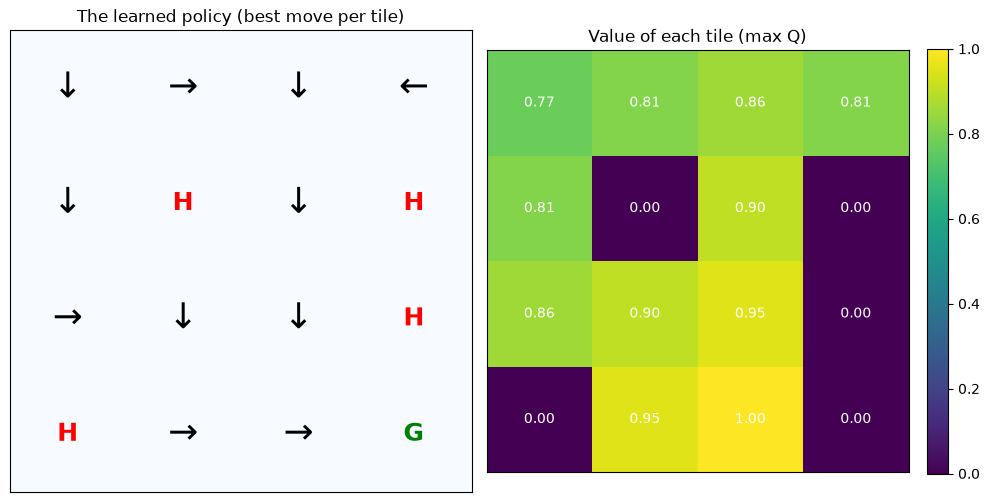

64 numbers = a complete skater's instinct for this pond.


In [13]:
ARROWS = {0: "←", 1: "↓", 2: "→", 3: "↑"}   # ← ↓ → ↑
desc = env.unwrapped.desc.astype(str)      # 4x4 grid of letters

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Left: the learned policy as arrows
ax1.imshow(np.zeros((4, 4)), cmap="Blues", vmin=0, vmax=1)
for s in range(16):
    r, c = divmod(s, 4)
    tile = desc[r, c]
    if tile == "H":
        ax1.text(c, r, "H", ha="center", va="center", fontsize=18, color="red", weight="bold")
    elif tile == "G":
        ax1.text(c, r, "G", ha="center", va="center", fontsize=18, color="green", weight="bold")
    else:
        ax1.text(c, r, ARROWS[int(best_action[s])], ha="center", va="center", fontsize=26)
ax1.set_title("The learned policy (best move per tile)")
ax1.set_xticks([]); ax1.set_yticks([])

# Right: how valuable each tile is (max Q)
im = ax2.imshow(best_value.reshape(4, 4), cmap="viridis")
for s in range(16):
    r, c = divmod(s, 4)
    ax2.text(c, r, f"{best_value[s]:.2f}", ha="center", va="center",
             color="white", fontsize=10)
ax2.set_title("Value of each tile (max Q)")
ax2.set_xticks([]); ax2.set_yticks([])
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print("64 numbers = a complete skater's instinct for this pond.")

## 6 · Watch it learn 🎥

You've dissected the finished brain — now watch it being **born**. This dashboard re-runs training from a **blank Q-table** (your Exercise-4 table `q` stays untouched), powered by the very functions *you* wrote: `choose_action` picks the moves, `get_epsilon` turns the exploration dial, and your Q-update line does the learning — live, on camera.

**How to read the dashboard:**
- **Left — the pond:** the elf actually skating (bright during 🎥 LIVE episodes, dimmed while ⏩ fast-forwarding).
- **Right — the cheat sheet as a map:** each tile shows its current best move, and **the greener a tile, the more reward the agent expects from it**. The orange box marks where the elf is standing. Hover any tile to see its four raw Q-values.
- **Top:** the episode counter, the exploration dial **ε** falling from 100% (pure dice) to 1% (pure cheat sheet), total wins, and the recent success rate.
- **Bottom:** the learning curve **building itself** — one bar per chunk of episodes.

We can't slow-play thousands of episodes, so the camera ⏩ **fast-forwards** through training and drops into 🎥 **slow-motion LIVE** at landmark episodes: **1, 2, 3** (pure random flailing — most end in 💧), then **10, 30, 100, 300, 1000**, and the **final** one (a confident beeline to the 🎁).

👀 **The thing to watch:** the green doesn't spread out from the start — it **grows backwards from the gift**. The tile beside the 🎁 learns first, then its neighbour, then the whole path lights up. That's your Q-update in action: every win pushes a little value one step further back along the route.

↓,→,↓,←
↓,💧,↓,💧
→,↓,↓,💧
💧,→,→,🎁

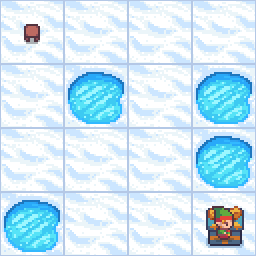

🏁 Watched 3,000 episodes: 1,263 wins · last-100 success 98% (this demo trained its own `q_watch` — your Exercise-4 table `q` is untouched)


In [14]:
# ══════════════════════════════════════════════════════════════════════
#  WATCH IT LEARN 🎥 — the training run, live on camera.
#  A fresh, blank Q-table (`q_watch`) trains before your eyes — your
#  Exercise-4 table `q` is left untouched. Fast-forward through the
#  boring parts, slow-motion 🎥 LIVE at landmark episodes.
# ══════════════════════════════════════════════════════════════════════
import io, time, base64
from PIL import Image as PILImage
from IPython.display import HTML, display

LANDMARKS = {1, 2, 3, 10, 30, 100, 300, 1000, EPISODES}   # episodes shown LIVE
FF_EVERY  = 25                        # fast-forward: redraw dashboard every N episodes
CHUNK     = max(10, EPISODES // 30)   # one learning-curve bar per CHUNK episodes
TILES     = env.unwrapped.desc.astype(str)   # the pond map: S, F, H, G

def frame_b64(frame):
    """Rendered numpy image → base64 PNG we can embed in live HTML."""
    buf = io.BytesIO()
    PILImage.fromarray(frame).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def cheatsheet_html(qt, agent_state=None):
    """The Q-table drawn as a map: best move per tile, greener = more promising.
    Hover any tile to see its four raw Q-values."""
    rows = ""
    for r in range(4):
        cells = ""
        for c in range(4):
            s, tile = 4 * r + c, TILES[r, c]
            hover = "  ".join(f"{ARROWS[a]} {qt[s, a]:.2f}" for a in range(4))
            style = "width:54px;height:54px;text-align:center;font-size:22px;border:1px solid #9fc3de;"
            if tile == "H":
                inner, style = "💧", style + "background:#16324a;"
            elif tile == "G":
                inner, style = "🎁", style + "background:#ffe9a8;"
            else:
                inner = ARROWS[int(np.argmax(qt[s]))] if qt[s].max() > 0 else "·"
                style += f"background:rgba(46,160,67,{qt[s].max():.2f});"   # greener = higher Q
            if s == agent_state:
                style += "outline:3px solid #ff6d00;outline-offset:-3px;"   # the elf is HERE
            cells += f"<td title='{hover}' style='{style}'>{inner}</td>"
        rows += f"<tr>{cells}</tr>"
    return f"<table style='border-collapse:collapse'>{rows}</table>"

def curve_html():
    """The learning curve, building itself one bar at a time."""
    if not rate_history:
        return ""
    bars = "".join(
        f"<div title='{v:.0f}%' style='width:11px;height:{max(2, v * 0.42):.0f}px;"
        f"background:#4c72b0;border-radius:2px 2px 0 0'></div>" for v in rate_history)
    return (f"<div style='display:flex;align-items:flex-end;gap:2px;height:46px;margin-top:8px'>{bars}</div>"
            f"<div style='color:#777'>the learning curve, building itself — one bar = % wins per {CHUNK} episodes</div>")

def draw_dash(banner, ep, eps, agent_state=None, live=False, note=""):
    """Redraw the whole dashboard in place."""
    pct = 100 * (ep + 1) / EPISODES
    rate = 100 * np.mean(recent) if recent else 0.0
    dim = "" if live else "opacity:0.45;"          # pond dims while fast-forwarding
    dash.update(HTML(
        f"<div style='font-family:monospace;font-size:13px;line-height:1.6'>"
        f"<div style='font-size:15px;white-space:nowrap'><b>{banner}</b></div>"
        f"<div style='white-space:nowrap'>episode <b style='font-size:16px'>{ep + 1:,}</b> / {EPISODES:,}"
        f" · 🎲 exploration ε = <b>{100 * eps:.0f}%</b>"
        f" · 🏆 wins <b>{wins}</b> · 📈 success rate (last 100) <b>{rate:.0f}%</b></div>"
        f"<div style='background:#e0e0e0;width:470px;height:8px;border-radius:4px;margin:3px 0'>"
        f"<div style='background:#4c72b0;width:{pct:.1f}%;height:8px;border-radius:4px'></div></div>"
        f"<div style='display:flex;gap:14px;margin-top:5px;align-items:flex-start'>"
        f"<img src='data:image/png;base64,{board_b64}' width='224' style='{dim}border-radius:4px'/>"
        f"{cheatsheet_html(q_watch, agent_state)}</div>"
        f"<div style='min-height:22px;font-size:14px'><b>{note}</b></div>"
        f"{curve_html()}</div>"))

# ── train a fresh cheat sheet, on camera ───────────────────────────────
q_watch = np.zeros((16, 4))               # blank: 64 zeros, zero knowledge
wins, chunk_wins, recent, rate_history = 0, 0, [], []
dash = display(HTML("<b>🎥 Setting up the training camera…</b>"), display_id=True)
env.reset()
board_b64 = frame_b64(env.render())

for ep in range(EPISODES):                             # the same loop as Exercise 4...
    eps = get_epsilon(ep, EPISODES)                    # ...run with YOUR functions
    state, _ = env.reset()
    live = (ep + 1) in LANDMARKS
    if live:
        board_b64 = frame_b64(env.render())
        style = ("the dice decide almost every move!" if eps > 0.5
                 else "the cheat sheet decides almost every move")
        draw_dash(f"🎥 LIVE — episode {ep + 1:,} begins", ep, eps, agent_state=state,
                  live=True, note=f"ε = {100 * eps:.0f}% → {style}")
        time.sleep(0 if SMOKE else (1.0 if ep < 3 else 0.5))
    done, step = False, 0
    while not done:
        step += 1
        action = choose_action(state, q_watch, eps)    # YOUR Exercise 2
        next_state, reward, terminated, truncated, _ = env.step(action)
        q_watch[state, action] += ALPHA * (reward + GAMMA * np.max(q_watch[next_state])
                                           - q_watch[state, action])   # YOUR Exercise 4 line
        state = next_state
        done = terminated or truncated
        if live:
            board_b64 = frame_b64(env.render())
            draw_dash(f"🎥 LIVE — episode {ep + 1:,} · step {step}", ep, eps,
                      agent_state=state, live=True)
            time.sleep(0 if SMOKE else (0.28 if ep < 3 and step <= 25 else 0.11))
    win = reward > 0
    wins += win
    chunk_wins += win
    recent = (recent + [win])[-100:]
    if (ep + 1) % CHUNK == 0:
        rate_history.append(100 * chunk_wins / CHUNK)
        chunk_wins = 0
    if live:
        note = ("🎁 GOT THE GIFT!" if win else
                "💧 splash — fell in a hole" if terminated else
                "⏰ time's up — wandered too long")
        draw_dash(f"🎥 episode {ep + 1:,} finished", ep, eps, live=True, note=note)
        time.sleep(0 if SMOKE else (1.3 if ep < 3 else 0.8))
    elif (ep + 1) % FF_EVERY == 0:
        draw_dash("⏩ fast-forwarding through training…", ep, eps,
                  note="watch the map turn green — knowledge spreading backwards from the gift 🎁")
        time.sleep(0 if SMOKE else 0.02)

final_rate = 100 * np.mean(recent)
draw_dash("🏁 TRAINING COMPLETE — the cheat sheet wrote itself", EPISODES - 1, eps,
          note=f"ε ended at {100 * eps:.0f}% · success over the last 100 episodes: {final_rate:.0f}%")
print(f"🏁 Watched {EPISODES:,} episodes: {wins:,} wins · last-100 success {final_rate:.0f}% "
      f"(this demo trained its own `q_watch` — your Exercise-4 table `q` is untouched)")

## 7 · Watch it play 🎬

Numbers are convincing; a replay is delightful. We run **one greedy episode** (no exploration — pure exploitation of the table), capture every frame, and stitch them into a GIF.

Saved 7 frames → /workspace/data/frozenlake_agent.gif


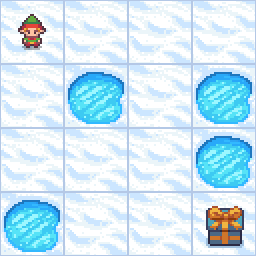

In [15]:
import imageio.v2 as imageio
from IPython.display import Image as IPImage, display

state, _ = env.reset(seed=SEED)
frames = [env.render()]
for _ in range(30):
    action = int(np.argmax(q[state]))          # greedy: always the best move
    state, reward, terminated, truncated, _ = env.step(action)
    frames.append(env.render())
    if terminated or truncated:
        break
env.close()

gif_path = REPO / "data" / "frozenlake_agent.gif"
imageio.mimsave(str(gif_path), frames, fps=3, loop=0)
print(f"Saved {len(frames)} frames → {gif_path}")
display(IPImage(filename=str(gif_path)))

## 8 · CartPole — when the cheat sheet explodes 🎪

The Q-table trick has a fatal limit. It works because FrozenLake has exactly **16 states** — you can list them in a table. Now meet **CartPole**: balance a pole upright by sliding a cart left or right. Its state is **four continuous numbers**:

`[cart position, cart velocity, pole angle, pole angular velocity]`

There are infinitely many possible states — you can't make a table with a row for every real number. So we **replace the table with a function that estimates Q-values**, and the best function approximator we know is a **neural network**. Feed it the 4 numbers, it outputs a Q-value for each action. That's a **Deep Q-Network (DQN)**.

Notice what just happened: **Day 5's neural networks have met today's rewards.** The course loops closed — the brains you built to *see* can also learn to *act*.

In [16]:
env2 = gym.make("CartPole-v1", render_mode="rgb_array")
obs, _ = env2.reset(seed=SEED)
print("A CartPole state is 4 continuous numbers:")
print("  [cart position, cart velocity, pole angle, pole angular velocity]")
print("  example:", np.round(obs, 3))
print("Actions: 0 = push cart LEFT, 1 = push cart RIGHT")
print("Reward: +1 for every step the pole stays up (500 = a perfect episode)")

A CartPole state is 4 continuous numbers:
  [cart position, cart velocity, pole angle, pole angular velocity]
  example: [ 0.027 -0.006  0.036  0.02 ]
Actions: 0 = push cart LEFT, 1 = push cart RIGHT
Reward: +1 for every step the pole stays up (500 = a perfect episode)


### 🧪 Exercise 7 — the CartPole baseline

Same idea as Exercise 1: measure how a **random** agent does before we train anything. Run 20 episodes of random actions and report the **average number of steps** the pole stays up.

Expected outcome: only about **~20–25 steps** — a random cart drops the pole almost immediately.

In [17]:
N_CARTPOLE = 20
baseline_env = gym.make("CartPole-v1")
baseline_env.action_space.seed(SEED)
lengths = []
for _ in range(N_CARTPOLE):
    obs, _ = baseline_env.reset()
    done, steps = False, 0
    ### BEGIN SOLUTION
    while not done:
        action = baseline_env.action_space.sample()      # flail randomly
        obs, reward, terminated, truncated, _ = baseline_env.step(action)
        steps += 1
        done = terminated or truncated
    ### HINT: count steps until the episode is terminated or truncated
    ### END SOLUTION
    lengths.append(steps)
baseline_env.close()
print(f"🎲 Random agent balanced the pole for {np.mean(lengths):.1f} steps on average (500 = perfect)")

🎲 Random agent balanced the pole for 27.2 steps on average (500 = perfect)


## 9 · Train a Deep Q-Network 🧠

Writing a solid DQN from scratch (replay buffers, target networks, the training loop) is a lot of careful code. Real labs don't reinvent it — they use a trusted library. We'll use **stable-baselines3** with a recipe tuned by the community for CartPole.

We train in **4 chunks** and evaluate after each one, so you can *watch* the mean reward climb from ~10 toward the maximum of 500. On a GPU the full run takes a few minutes; in smoke-test mode it's just a quick sanity pass.

In [18]:
from stable_baselines3 import DQN

eval_env = gym.make("CartPole-v1")

def evaluate(model, n_episodes=5):
    """Average total reward over a few *greedy* (deterministic) episodes."""
    returns = []
    for _ in range(n_episodes):
        obs, _ = eval_env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = eval_env.step(int(action))
            total += reward
            done = terminated or truncated
        returns.append(total)
    return float(np.mean(returns))

# Hyperparameters from the stable-baselines3 rl-zoo recipe for CartPole:
model = DQN("MlpPolicy", env2, learning_rate=2.3e-3, batch_size=64,
            buffer_size=100_000, learning_starts=1_000, gamma=0.99,
            target_update_interval=10, train_freq=256, gradient_steps=128,
            exploration_fraction=0.16, exploration_final_eps=0.04,
            policy_kwargs=dict(net_arch=[256, 256]), seed=SEED,
            device=DEVICE, verbose=0)

chunk = max(1, TIMESTEPS // 4)
print(f"Training the DQN for ~{TIMESTEPS} steps in 4 chunks (watch the reward climb)...")
for i in range(4):
    model.learn(total_timesteps=chunk, reset_num_timesteps=False, progress_bar=False)
    mean_reward = evaluate(model)
    print(f"  chunk {i+1}/4  (~{(i+1)*chunk:>6} steps)  mean reward = {mean_reward:6.1f}  (500 = perfect)")

print("🏁 DQN training complete!")

Training the DQN for ~60000 steps in 4 chunks (watch the reward climb)...
  chunk 1/4  (~ 15000 steps)  mean reward =  102.8  (500 = perfect)
  chunk 2/4  (~ 30000 steps)  mean reward =  165.8  (500 = perfect)
  chunk 3/4  (~ 45000 steps)  mean reward =  500.0  (500 = perfect)
  chunk 4/4  (~ 60000 steps)  mean reward =  500.0  (500 = perfect)
🏁 DQN training complete!


## 10 · Before vs. after — the wow moment ✨

Time for a **live head-to-head match**: same game, two players, **side by side**. On the left, an untrained agent mashing random buttons; on the right, **your trained DQN**. They play 3 episodes **at the same time, from the exact same starting state**, so you can compare every single decision in real time:

- while **both** are alive the match runs in 🐌 **slow motion** — compare the ⬅️/➡️ choices each brain makes and watch each pole angle (it turns red near the fatal **±12°**);
- the moment one loses, its panel **freezes on the crash** with a verdict (💥 *and why* — pole past ±12°, or cart off the edge) while the survivor plays on in ⏩ **fast-forward**;
- between episodes there's a short countdown, and a **results table** fills in as the match unfolds, ending with a final scoreboard.

At the end you get a **🔁 Replay button** to run the whole match again — the random agent plays different moves every time. (Each agent's last episode is also quietly saved as a GIF in `data/`.)

,🎲 Random,🧠 DQN
episode 1,💥 pole fell · 21 steps,🏆 500 steps
episode 2,💥 pole fell · 98 steps,🏆 500 steps
episode 3,💥 pole fell · 23 steps,🏆 500 steps

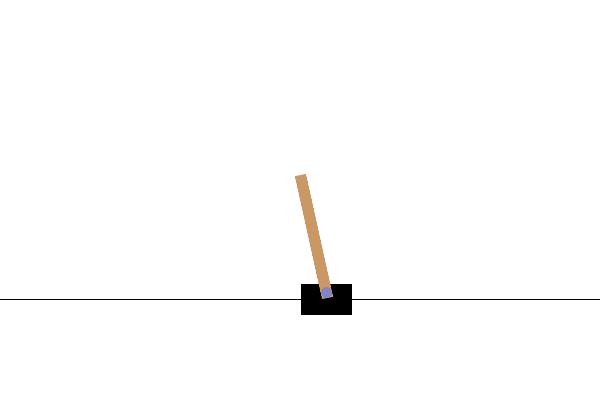
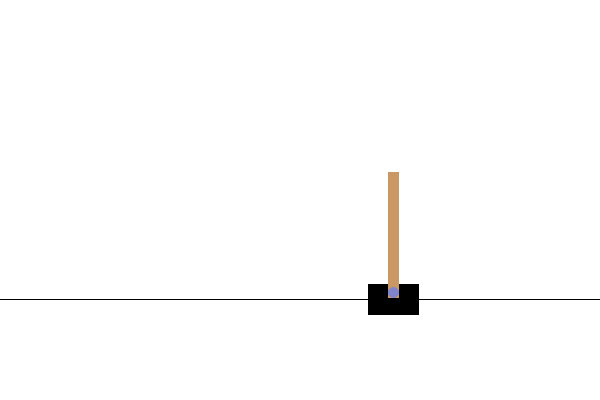

Button(button_style='success', description='🔁 REPLAY the match!', layout=Layout(height='36px', width='240px'),…

☝️ Click to replay the match above — the random agent plays new moves every time!


In [19]:
# ══════════════════════════════════════════════════════════════════════
#  THE MATCH 🥊 — both agents play the SAME episodes side by side, live.
#  Slow motion while both survive, freeze + verdict when one crashes,
#  a results table that fills in, and a 🔁 Replay button at the end.
# ══════════════════════════════════════════════════════════════════════
import io, time, base64
import imageio.v2 as imageio
from PIL import Image as PILImage
from IPython.display import HTML, display

N_EPISODES = 1 if SMOKE else 3        # episodes in the match
PAUSE      = 0.0 if SMOKE else 1.0    # base pause for freezes & countdowns (s)
MAX_STEPS  = 500                      # CartPole's own limit — 500 = a perfect game
SLOW = (1, 0.08)   # (draw every Nth frame, delay) while BOTH are still alive
FAST = (2, 0.02)   # ...and once somebody has crashed (fast-forward)

# CartPole's actual losing conditions — watch for them in the live panels!
POLE_LIMIT_DEG = 12.0    # game over if the pole tips more than ±12° ...
CART_LIMIT_X   = 2.4     # ... or the cart slides off the screen edge (±2.4)

def frame_b64(frame):
    """Rendered numpy image → base64 PNG we can embed in live HTML."""
    buf = io.BytesIO()
    PILImage.fromarray(frame).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

def verdicts(terminated, obs, steps):
    """(long text for the player card, short text for the results table)."""
    if not terminated:
        return (f"🏆 PERFECT — survived all {steps} steps, the pole never fell!",
                f"🏆 {steps} steps")
    if abs(np.degrees(obs[2])) > POLE_LIMIT_DEG:
        return (f"💥 GAME OVER — pole tipped past ±{POLE_LIMIT_DEG:.0f}° after {steps} steps",
                f"💥 pole fell · {steps} steps")
    return (f"💥 GAME OVER — cart slid off the screen after {steps} steps",
            f"💥 cart off edge · {steps} steps")

class Player:
    """One contestant: its brain, its own copy of the game, and its live stats."""
    def __init__(self, name, brain, color):
        self.name, self.brain, self.color = name, brain, color
        self.env = gym.make("CartPole-v1", render_mode="rgb_array")
        self.env.action_space.seed(SEED)
        self.scores = []

    def begin_episode(self, ep):
        self.obs, _ = self.env.reset(seed=SEED + ep)   # both players get the SAME start!
        self.done, self.steps, self.action = False, 0, 1
        self.verdict = self.short = ""
        self.frames = []                               # the GIF keeps the last episode
        self.snap()

    def snap(self):
        """Capture the current screen for the live panel + the GIF."""
        frame = self.env.render()
        self.frames.append(frame)
        self.b64 = frame_b64(frame)

    def play_step(self):
        if self.done:
            return                                        # stays frozen on its crash frame
        if self.brain is None:
            self.action = self.env.action_space.sample()  # random button-mashing
        else:
            a, _ = self.brain.predict(self.obs, deterministic=True)
            self.action = int(a)
        self.obs, _r, terminated, truncated, _ = self.env.step(self.action)
        self.steps += 1
        if terminated or truncated:
            self.done = True
            self.scores.append(self.steps)
            self.verdict, self.short = verdicts(terminated, self.obs, self.steps)
            self.snap()                                   # keep the crash frame on screen

def card_html(p):
    """One player's panel: name, live stats (or verdict), progress bar, frame."""
    if p.done:
        col = "#2ca02c" if p.short.startswith("🏆") else "#d62728"
        status = f"<b style='color:{col}'>{p.verdict}</b>"
    else:
        deg = np.degrees(p.obs[2])
        col = "#d62728" if abs(deg) > 0.75 * POLE_LIMIT_DEG else "#2ca02c"
        push = "⬅️ pushing LEFT" if p.action == 0 else "➡️ pushing RIGHT"
        status = (f"<div style='white-space:nowrap'>step <b>{p.steps:3d}</b>/{MAX_STEPS} · {push}</div>"
                  f"<div style='white-space:nowrap'>pole angle <b style='color:{col}'>{deg:+5.1f}°</b> (±{POLE_LIMIT_DEG:.0f}° = fall) · "
                  f"cart x <b>{p.obs[0]:+.2f}</b> (±{CART_LIMIT_X} = edge)</div>")
    bar = min(100.0, 100.0 * p.steps / MAX_STEPS)
    return (f"<div style='flex:1;min-width:490px;max-width:560px'>"
            f"<div style='font-size:15px'><b>{p.name}</b></div>"
            f"<div style='min-height:46px'>{status}</div>"
            f"<div style='background:#e0e0e0;height:9px;border-radius:5px'>"
            f"<div style='background:{p.color};width:{bar:.1f}%;height:9px;border-radius:5px'></div></div>"
            f"<img src='data:image/png;base64,{p.b64}' style='width:100%;margin-top:5px;border:1px solid #ccc;border-radius:4px'/>"
            f"</div>")

def history_html(history):
    """The episode-by-episode results table (fills in as the match unfolds)."""
    if not history:
        return ""
    rows = "".join(
        f"<tr><td style='padding:1px 12px 1px 0'><b>episode {ep}</b></td>"
        f"<td style='padding:1px 12px'>{a}</td><td style='padding:1px 12px'>{b}</td></tr>"
        for ep, a, b in history)
    return (f"<table style='margin-top:8px;border-collapse:collapse'>"
            f"<tr><td></td><td style='padding:1px 12px'><b>🎲 Random</b></td>"
            f"<td style='padding:1px 12px'><b>🧠 DQN</b></td></tr>{rows}</table>")

def draw(banner, history, footer=""):
    """Redraw the whole match panel in place (banner, both cards, results, footer)."""
    cards = "".join(card_html(p) for p in players)
    screen.update(HTML(
        f"<div style='font-family:monospace;font-size:13px;line-height:1.5'>"
        f"<div style='font-size:15px'><b>{banner}</b></div>"
        f"<div style='display:flex;gap:10px;margin-top:6px;overflow-x:auto'>{cards}</div>"
        f"{history_html(history)}{footer}</div>"))

def run_match():
    """Play the full match (all episodes) — also re-run by the 🔁 Replay button."""
    history = []
    for p in players:
        p.scores = []                                     # fresh scoreboard each match

    for ep in range(1, N_EPISODES + 1):
        for p in players:
            p.begin_episode(ep)
        draw(f"🥊 Episode {ep} of {N_EPISODES} — same start, two brains. GO!", history)
        time.sleep(PAUSE * 0.8)

        for step in range(1, MAX_STEPS + 1):
            for p in players:
                p.play_step()                             # both act on the SAME tick
            everyone_done = all(p.done for p in players)
            both_alive = all(not p.done for p in players)
            fe, dl = SLOW if both_alive else FAST         # slow-mo → fast-forward
            if step % fe == 0 or everyone_done:
                for p in players:
                    if not p.done:
                        p.snap()
                phase = "🐌 slow motion — both alive!" if both_alive else "⏩ fast-forward"
                draw(f"🥊 Episode {ep} of {N_EPISODES} · {phase}", history)
                time.sleep(0.0 if SMOKE else dl)
            if everyone_done:
                break

        for p in players:                                 # safety net (never hit at 500)
            if not p.done:
                p.done = True
                p.scores.append(p.steps)
                p.verdict, p.short = verdicts(False, p.obs, p.steps)
        history.append((ep, players[0].short, players[1].short))
        draw(f"🏁 Episode {ep} finished — read the verdicts!", history)
        time.sleep(PAUSE * 1.6)                           # let the result sink in
        if ep < N_EPISODES:
            for t in (3, 2, 1):
                draw(f"⏳ New episode starting in {t}…", history)
                time.sleep(PAUSE * 0.7)

    ravg, davg = (float(np.mean(p.scores)) for p in players)
    footer = (f"<div style='margin-top:10px;border-top:2px solid #888;padding-top:6px'>"
              f"<b>🏆 FINAL SCOREBOARD — steps the pole stayed up ({MAX_STEPS} = perfect)</b><br>"
              f"🎲 Random agent : best <b>{max(players[0].scores)}</b> · average <b>{ravg:.1f}</b><br>"
              f"🧠 Trained DQN : best <b>{max(players[1].scores)}</b> · average <b>{davg:.1f}</b><br>"
              f"→ the trained brain lasted <b>{davg / ravg:.0f}×</b> longer — "
              f"same game, same physics, only the brain changed.</div>")
    draw("🏆 MATCH OVER — final results:", history, footer)
    imageio.mimsave(str(RAND_GIF), players[0].frames, fps=25, loop=0)
    imageio.mimsave(str(DQN_GIF),  players[1].frames, fps=25, loop=0)

# ── set up the two contestants and play the match ──────────────────────
players = [Player("🎲 Random agent", None,  "#ff7f0e"),
           Player("🧠 Trained DQN",  model, "#4c72b0")]
RAND_GIF = REPO / "data" / "cartpole_random.gif"   # each agent's last episode is
DQN_GIF  = REPO / "data" / "cartpole_trained.gif"  # quietly saved as a GIF file

screen = display(HTML("<b>🥊 The match is about to begin…</b>"), display_id=True)
run_match()

# ── the 🔁 Replay button (falls back to a hint if widgets are missing) ─
try:
    import ipywidgets as widgets
    replay_btn = widgets.Button(description="🔁 REPLAY the match!", button_style="success",
                                layout=widgets.Layout(width="240px", height="36px"))
    def on_replay(_):
        replay_btn.disabled = True          # no double-clicks mid-match
        try:
            run_match()                     # re-drives the live panel up above ☝️
        finally:
            replay_btn.disabled = False
    replay_btn.on_click(on_replay)
    display(replay_btn)
    print("☝️ Click to replay the match above — the random agent plays new moves every time!")
except Exception:
    print("🔁 To watch the match again, just re-run this cell.")

## 🔓 Unlock your Studio module

The 🎮 **Game Master** needs two files: the **Q-table** (`.npy`) and the **trained DQN** (`.zip`). Save both into your Studio's models folder to light up the tab.

In [20]:
REQUIRED_FILES = ["game_master_qtable.npy", "game_master_dqn.zip"]

np.save(MODELS_DIR / "game_master_qtable.npy", q)
model.save(str(MODELS_DIR / "game_master_dqn.zip"))   # sb3 keeps the ".zip" name exactly as given

missing = [f for f in REQUIRED_FILES if not (MODELS_DIR / f).exists()]
assert not missing, f"Something didn't save: {missing}"

print("🔓 UNLOCKED: 🎮 Game Master!")
for f in REQUIRED_FILES:
    kb = (MODELS_DIR / f).stat().st_size / 1024
    print(f"   ✅ {f}  ({kb:.1f} KB)")
print("\nRun your Studio to play against both agents you trained:")
print("   python ai_studio/app.py   (from the repo root)")

🔓 UNLOCKED: 🎮 Game Master!
   ✅ game_master_qtable.npy  (0.6 KB)
   ✅ game_master_dqn.zip  (1081.9 KB)

Run your Studio to play against both agents you trained:
   python ai_studio/app.py   (from the repo root)


## 🏁 Checkpoint

Today you crossed from **perceiving** to **acting**. You:

- Learned the **reinforcement-learning loop** — act, receive a reward and a new state, update your beliefs, repeat.
- Trained a **Q-table** on FrozenLake: 64 numbers that grew from all-zeros into a flawless instinct for the pond.
- Wrote the **Q-learning update** — the single line that turns raw experience into knowledge.
- Trained a **Deep Q-Network** on CartPole, where a neural network *replaces* the table — Day 5's brains meeting today's rewards.
- Unlocked the 🎮 **Game Master** in your Studio.

That's **seven modules built**. And here's the quiet truth about every one of them — the penguin classifier, the digit reader, the language models, today's agents: none were *programmed* with the answer. Each started knowing nothing and got better, from data or from rewards. Every capability in your Studio was **trained**.

**Tomorrow is Demo Day.** You'll assemble the entire AI Studio, rehearse your demo, and then run the **Grand Benchmark** — where we uncover the single mathematical operation humming underneath all seven modules, and discover why making it *fast* is the whole adventure of Weeks 3–4. See you there. 🚀

---

<div align="center" style="background:#14161E;border-radius:12px;padding:18px 12px 14px;margin-top:6px">
  <a href="https://ahalimi.com" target="_blank">
    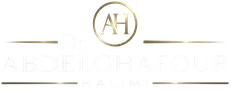
  </a>
</div>

<div align="center" style="text-align:center;margin-top:8px"><sub>The Lab · AI Studio Internship — © 2026 <b>Dr. Abdelghafour HALIMI</b> · <a href="https://ahalimi.com">ahalimi.com</a> · All rights reserved.</sub></div>